In [1]:
# Import and create models
import TailKinematicsNN
import ThrustNN
import torch 

TailKinematicsModel = TailKinematicsNN.TailKinematicsRNN(num_layers=1)

# Thrust Model initializations
input_size = 16
hidden_layers = 5
npl = 32
output_size = 7
ThrustModel = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=npl, output_size=output_size, hidden_layers=hidden_layers, dropout_enabled=True)

# print(TailKinematicsModel)

In [2]:
# Load model weights from pretrained models
import torch

TailKinematicsModel.load_state_dict(torch.load('./TailKinematics/kinematicsMoments_radians1.pt'))
ThrustModel.load_state_dict(torch.load('./Thrust/simple_data_modelv2_32_neurons_5_layers.pt'))
# ThrustModel.load_state_dict(torch.load('./Models/no_dropout4_neurons_3_layers.pt'))
# ThrustModel.load_state_dict(torch.load('./Models/no_dropout16_neurons_5_layers.pt'))

<All keys matched successfully>

In [3]:
# load Matlab data
import scipy.io
import numpy as np

data = scipy.io.loadmat('./Data/data2025-10-18_00-01-54.mat')
data_keys = ['xout', 'Tail_Forces_out', 'Tail_Centre_out', 'cout', 'cal_stout', 'Moments_Add_out']

# Create a dictionary to hold the data (labels as keys and numpy arrays as values)
data_dict = {key: np.array(data[key]) for key in data_keys}


In [4]:
import math
print(data_dict['cal_stout'].shape)  # Example: print the shape of 'cal_stout' data
data_dict['cal_stout'] = data_dict['cal_stout'][:, :8]  # Keep only the first 8 columns

# Prepare input kinematics tensor (8 motor angular positions + tail centre position))
in_kinematics = np.hstack((data_dict['cal_stout'], data_dict['Tail_Centre_out']))
print(f'Kinematics data before conversion to radians in_kinematics: {in_kinematics[125]}')
kinematics_tensor = torch.from_numpy(in_kinematics).float().unsqueeze(-1)*math.pi/180  # Add batch dimension
print(kinematics_tensor.shape)
print(f'Kinematics data after conversion to radians kinematics_tensor: {kinematics_tensor[125]}')
out_kinematics = np.hstack((data_dict['Moments_Add_out'], data_dict['cout'])) # Target output: moments + caudal amplitude + angle
kinematics_target = torch.from_numpy(out_kinematics).float()
kinematics_target[:, -1] = kinematics_target[:, -1]*math.pi/180  # Convert caudal theta to radians
print(kinematics_target.shape)

(10000, 10)
Kinematics data before conversion to radians in_kinematics: [ 4.56399448  5.19281797  4.84160051  5.47460236  5.10824702  6.71958426
  7.35102888  7.9903645  59.04      ]
torch.Size([10000, 9, 1])
Kinematics data after conversion to radians kinematics_tensor: tensor([[0.0797],
        [0.0906],
        [0.0845],
        [0.0955],
        [0.0892],
        [0.1173],
        [0.1283],
        [0.1395],
        [1.0304]])
torch.Size([10000, 3])


In [5]:
# Test the Tail Kinematics Model and measure time
import time
with torch.no_grad():
    TailKinematicsModel.eval()
    start_time = time.time()
    kinematics_preds = TailKinematicsModel(kinematics_tensor)
    end_time = time.time()
    total_time = end_time - start_time
    mean_time_per_sample = total_time / kinematics_tensor.shape[0]
    print(kinematics_preds.shape)
    print(f"Time taken: {total_time} seconds")
    print(f"Mean time per sample: {mean_time_per_sample} seconds")


torch.Size([10000, 3])
Time taken: 0.02630448341369629 seconds
Mean time per sample: 2.630448341369629e-06 seconds


In [6]:
# Compare predicted vs actual kinematics (mse, r2, ils)
from torcheval.metrics.functional import r2_score, mean_squared_error

mse_kinematics = mean_squared_error(kinematics_preds, kinematics_target)
r2_kinematics = r2_score(kinematics_preds, kinematics_target)

print(f"Kinematics Model - MSE: {mse_kinematics.item()}, R2: {r2_kinematics.item()}")


Kinematics Model - MSE: 9.289338777307421e-06, R2: 0.9958520531654358


In [7]:
# Prepare input for Thrust Model with simulation data
#load scalers used during training
import joblib
scaler_in = joblib.load('./Thrust/scaler_thrust_in.pkl')
scaler_out = joblib.load('./Thrust/scaler_thrust_out.pkl')
# Concatenate inputs for Thrust Model
caudal_old = np.hstack((np.zeros(1),data_dict['cout'][:-1, 0])).reshape(-1,1)  # Previous caudal angle (shifted by one timestep)
print(caudal_old.shape)
in_thrust = np.hstack((data_dict['xout'], data_dict['cout'], caudal_old, data_dict['Tail_Centre_out']))  # Input: fluid velocity, caudal angle, previous caudal angle, tail forces
print(in_thrust.shape)
# Scale input data 
in_thrust = scaler_in.transform(in_thrust)  # Scale input data
# Convert to tensor
in_thrust_tensor = torch.from_numpy(in_thrust).float()

# Prepare target output for Thrust Model
thrust_target = data_dict['Tail_Forces_out']  # Target output: thrust forces
print(thrust_target.shape)
# Exclude all columns that are zero constants
thrust_target = thrust_target[:, ~np.all(thrust_target == 0, axis=0)]
# Scale target data
thrust_target = scaler_out.transform(thrust_target)  # Scale target data
# Convert to tensor
thrust_target_tensor = torch.from_numpy(thrust_target).float()
print(thrust_target_tensor.shape)

(10000, 1)
(10000, 16)
(10000, 12)
torch.Size([10000, 7])


In [8]:
with torch.no_grad():
    ThrustModel.eval()
    thrust_preds = ThrustModel(in_thrust_tensor)
    print(thrust_preds.shape)

torch.Size([10000, 7])


In [9]:
# Compare predicted vs actual kinematics (mse, r2, ils)
from torcheval.metrics.functional import r2_score, mean_squared_error

mse_thrust = mean_squared_error(thrust_preds, thrust_target_tensor)
r2_thrust = r2_score(thrust_preds, thrust_target_tensor)

print(f"Thrust Model - MSE: {mse_thrust.item()}, R2: {r2_thrust.item()}")

Thrust Model - MSE: 0.37166911363601685, R2: 0.8958932161331177


C:\Users\brend\AppData\Local\Temp\ipykernel_31108\1980590410.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


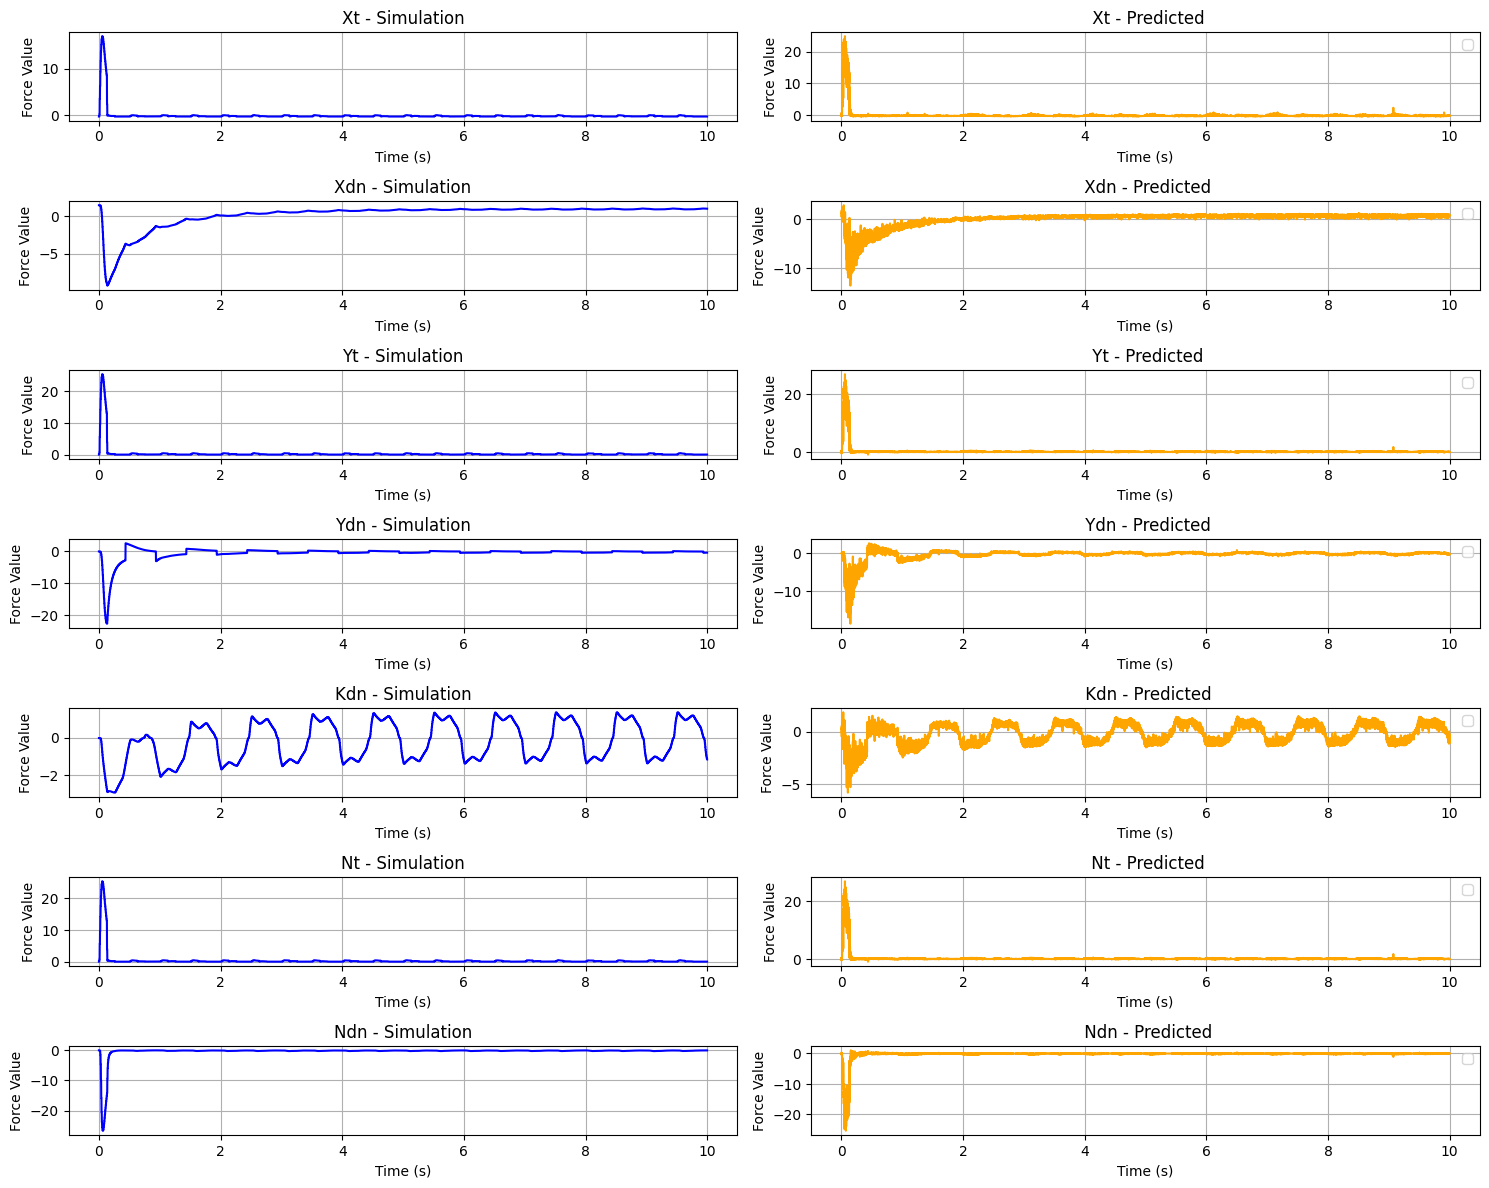

In [10]:
# Plot 12 Tail Forces Comparison 
import matplotlib.pyplot as plt 
#force_labels = ['Xt', 'Xdn', 'Yt', 'Ydn', 'Zt', 'Zdn', 'Kt', 'Kdn', 'Mt', 'Mdn', 'Nt', 'Ndn']
force_labels = ['Xt', 'Xdn', 'Yt', 'Ydn', 'Kdn', 'Nt', 'Ndn']
time = np.arange(thrust_target_tensor.shape[0]) * 1e-3   
plt.figure(figsize=(15, 20))
for i in range(thrust_target_tensor.shape[1]):
    plt.subplot(12, 2, (i*2)+1)
    plt.plot(time, thrust_target_tensor[:, i], color='blue')
    plt.title(f'{force_labels[i]} - Simulation')
    plt.xlabel('Time (s)')
    plt.ylabel('Force Value')
    plt.grid()
    plt.subplot(12, 2, (i*2)+2)
    plt.plot(time, thrust_preds[:, i].numpy(), color='orange')
    plt.title(f' {force_labels[i]} - Predicted')
    plt.xlabel('Time (s)')
    plt.ylabel('Force Value')
    plt.legend()
    plt.grid()
plt.tight_layout()

In [11]:
# Test thrust model with kinematics model output
caudal_old = np.hstack((np.zeros(1),kinematics_preds[:, -2].numpy()[:-1])).reshape(-1,1)  # Previous caudal angle (shifted by one timestep)
print(caudal_old.shape)
in_thrust = np.hstack((data_dict['xout'], kinematics_preds[:, -2:].numpy(), caudal_old, data_dict['Tail_Centre_out']))  # Input: fluid velocity, caudal angle, previous caudal angle, tail forces
print(in_thrust.shape)
# Scale input data 
in_thrust = scaler_in.transform(in_thrust)  # Scale input data
# Convert to tensor
in_thrust_tensor = torch.from_numpy(in_thrust).float()

(10000, 1)
(10000, 16)


In [12]:
with torch.no_grad():
    ThrustModel.eval()
    thrust_preds = ThrustModel(in_thrust_tensor)
    print(thrust_preds.shape)

torch.Size([10000, 7])


In [13]:
# Compare predicted vs actual kinematics (mse, r2, ils)
from torcheval.metrics.functional import r2_score, mean_squared_error
import time
# Get prediction time
start_time = time.time()
mse_thrust = mean_squared_error(thrust_preds, thrust_target_tensor)
r2_thrust = r2_score(thrust_preds, thrust_target_tensor)
end_time = time.time()
print(f"Prediction Time per prediction: {(end_time - start_time)/len(thrust_preds)} seconds")

print(f"Thrust Model - MSE: {mse_thrust.item()}, R2: {r2_thrust.item()}")

Prediction Time per prediction: 2.0983219146728515e-07 seconds
Thrust Model - MSE: 0.762111246585846, R2: 0.7930501103401184


In [14]:
# Inverse transform predictions and targets to original scale for better interpretability
thrust_preds_np = thrust_preds.numpy()
thrust_target_np = thrust_target_tensor.numpy()
thrust_preds_original = scaler_out.inverse_transform(thrust_preds_np)
thrust_targets_original = scaler_out.inverse_transform(thrust_target_np)

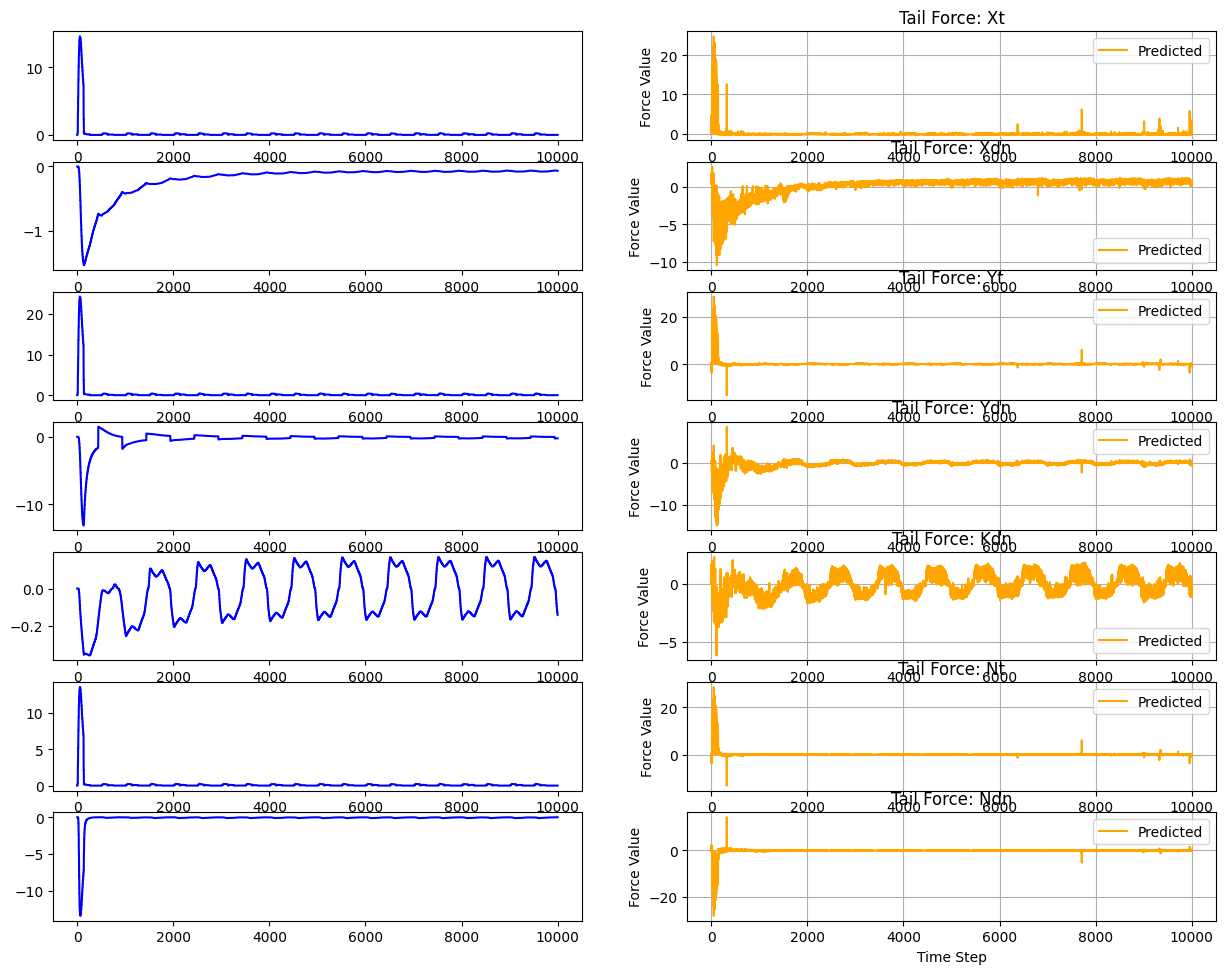

In [15]:
# Plot 12 Tail Forces Comparison 
import matplotlib.pyplot as plt 
#force_labels = ['Xt', 'Xdn', 'Yt', 'Ydn', 'Zt', 'Zdn', 'Kt', 'Kdn', 'Mt', 'Mdn', 'Nt', 'Ndn']
force_labels = ['Xt', 'Xdn', 'Yt', 'Ydn', 'Kdn', 'Nt', 'Ndn']
time = np.arange(thrust_targets_original.shape[0])  # Assuming each row corresponds to a timestep      
plt.figure(figsize=(15, 20))
for i in range(thrust_targets_original.shape[1]):
    plt.subplot(12, 2, (i*2)+1)
    plt.plot(time, thrust_targets_original[:, i], label='Actual', color='blue')
    plt.subplot(12, 2, (i*2)+2)
    plt.plot(time, thrust_preds[:, i].numpy(), label='Predicted', color='orange')
    plt.title(f'Tail Force: {force_labels[i]}')
    plt.xlabel('Time Step')
    plt.ylabel('Force Value')
    plt.legend()
    plt.grid()

In [16]:
# Test Rigid Body Model
import RigidBody.RigidBodyNN as RigidBodyNN

RigidBodyModel = RigidBodyNN.RigidBodyNN(u_size=8, x_size=12, n_neurons=64)
RigidBodyModel.load_state_dict(torch.load('./RigidBody/rigid_body_nn_model_clean_input.pth'))


<All keys matched successfully>

In [17]:
# Load scalers for Rigid Body Model
scaler_rb_u = joblib.load('./RigidBody/u_scaler_clean.pkl')
scaler_rb_x = joblib.load('./RigidBody/x_scaler_clean.pkl')

In [18]:
# %%
# Runge-Kutta 4th order method for ODE solving
def rk4_step_func(func, x0, u, dt):
    k1 = func(x0, u)
    k1 = k1*dt

    k2 = func(x0+k1/2, u)
    k2 = k2*dt

    k3 = func(x0+k2/2, u)
    k3 = k3*dt

    k4 = func(x0+k3, u)
    k4 = k4*dt

    return x0 + (k1 + 2 * (k2 + k3) + k4) / 6

In [29]:
# Test Rigid Body Model with Tail Kinematics and Thrust Model output
# Prepare input for Rigid Body Model
# Rigid Body variables

dt = 1e-3  # Time step for simulation
N = kinematics_tensor.shape[0]  # Number of timesteps
rigid_body_states = np.zeros((12), dtype=np.float32)  # Placeholder for rigid body states
rigid_body_u_signals = np.zeros((8), dtype=np.float32)  # Placeholder for rigid body control inputs
rigid_body_states_history = np.zeros((N, 1, 12), dtype=np.float32)  # History of rigid body states

for t in range(N):
    rigid_body_u_signals[:7] = thrust_preds_original[t]
    rigid_body_u_signals[7] = kinematics_preds[t, 0].item()  # Caudal angle from kinematics model
    # Scale inputs
    rigid_body_states_scaled = scaler_rb_x.transform(rigid_body_states.reshape(1, -1))
    rigid_body_u_scaled = scaler_rb_u.transform(rigid_body_u_signals.reshape(1, -1))
    # Convert to tensors
    rigid_body_states_tensor = torch.from_numpy(rigid_body_states_scaled).float()
    rigid_body_u_tensor = torch.from_numpy(rigid_body_u_scaled).float()

    # Predict next state
    with torch.no_grad():
        RigidBodyModel.eval()
        next_state_scaled = rk4_step_func(RigidBodyModel, rigid_body_states_tensor, rigid_body_u_tensor, dt=5e-3)
    # Inverse scale the next state
    next_state = scaler_rb_x.inverse_transform(next_state_scaled.numpy())
    rigid_body_states = next_state.flatten()
    rigid_body_states_history[t, 0, :] = rigid_body_states

In [30]:
# Load true rigid body states for comparison
true_rigid_body_states = data_dict['xout']  # True rigid body states from data

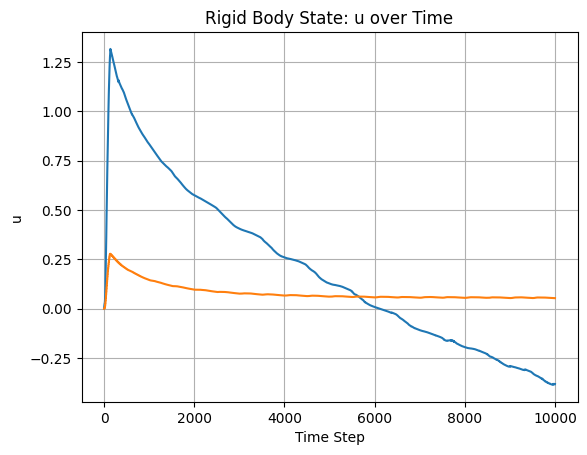

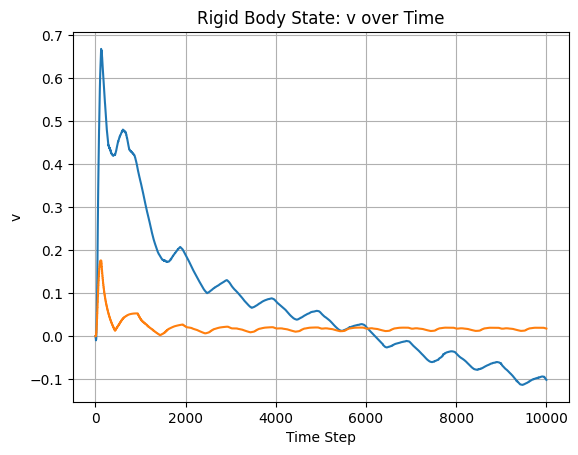

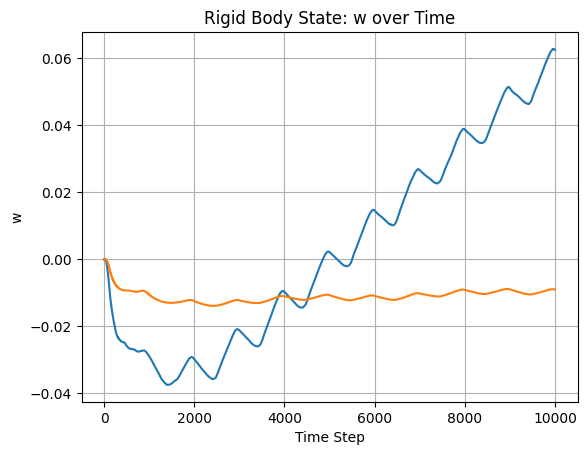

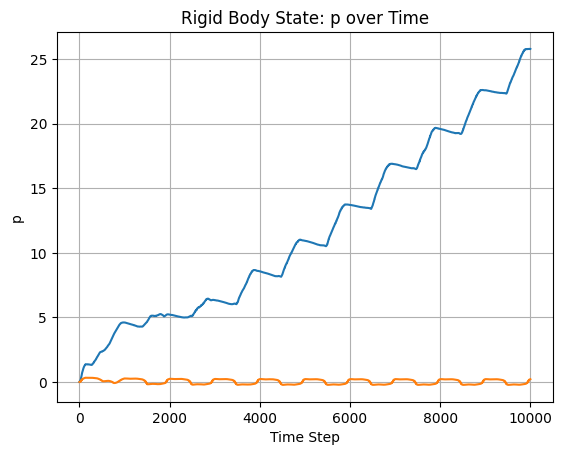

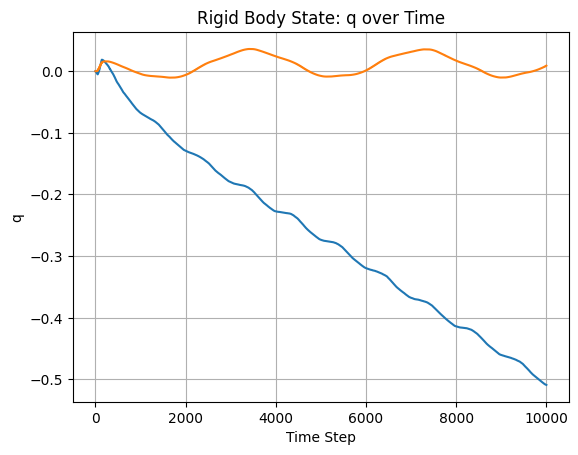

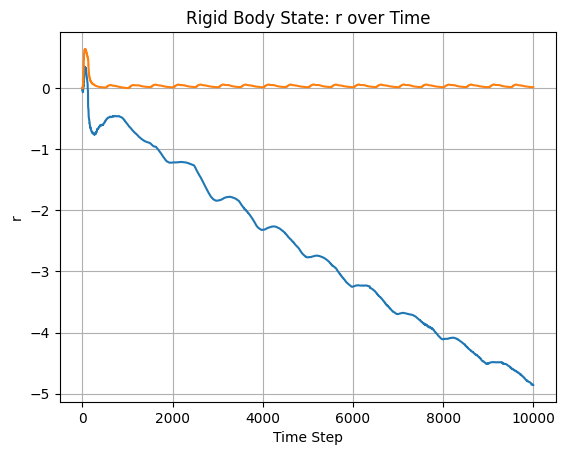

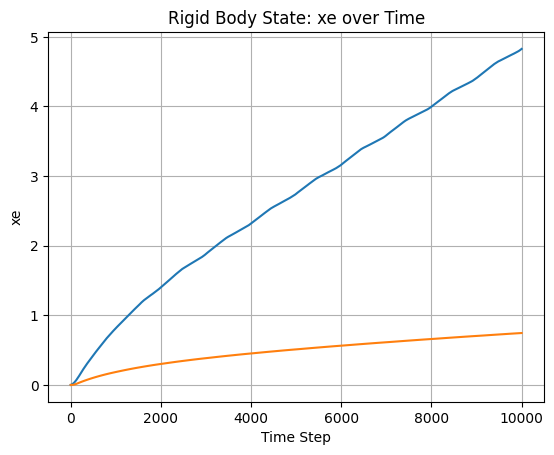

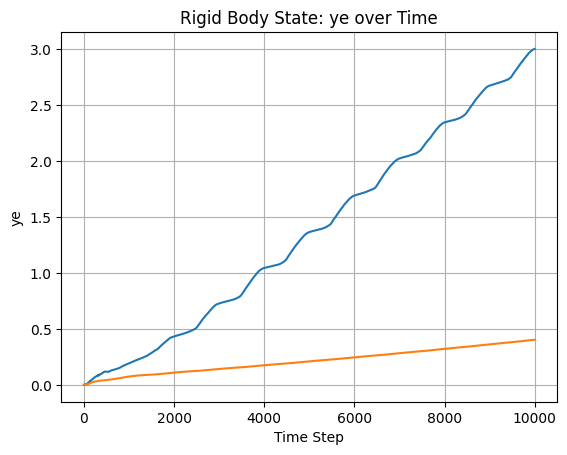

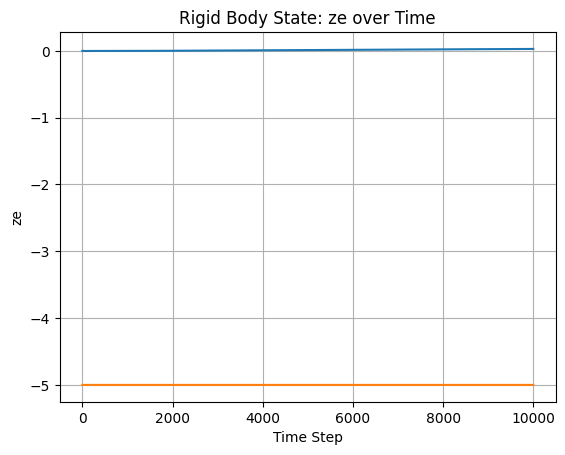

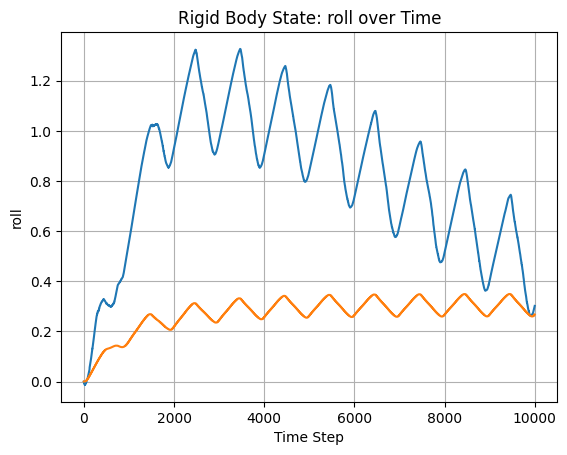

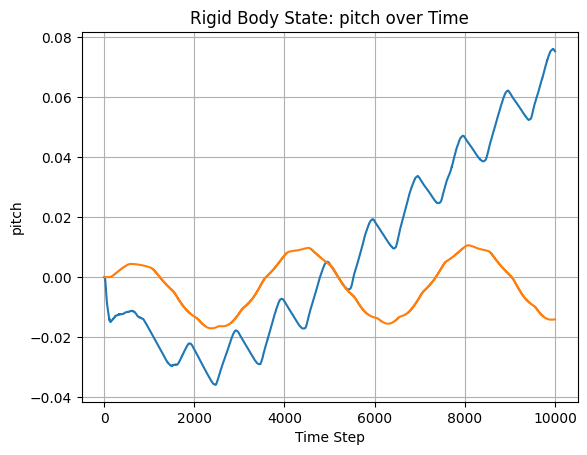

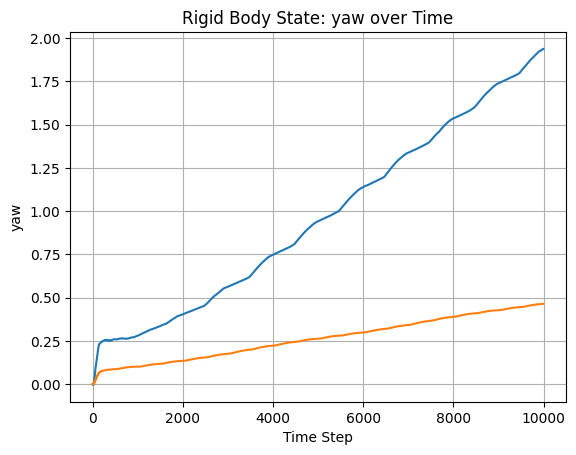

In [31]:
# Plot Rigid Body States over time
x_labels = ['u', 'v', 'w', 'p', 'q', 'r', 'xe', 'ye', 'ze', 'roll', 'pitch', 'yaw']

for i in range(rigid_body_states_history.shape[2]):
    plt.figure()
    plt.plot(rigid_body_states_history[:, 0, i])
    plt.plot(true_rigid_body_states[:, i])
    plt.title(f'Rigid Body State: {x_labels[i]} over Time')
    plt.xlabel('Time Step')
    plt.ylabel(x_labels[i])
    plt.grid()

In [22]:
# Test both models in sequence no CUDA
import time
TailKinematicsModel.eval()
ThrustModel.eval()
# Save starting time
t_start = time.perf_counter()
t_total = 0.0
caudal_amplitude_old = 0.0  # Initial previous caudal angle
for i in range(kinematics_preds.shape[0]):
    # Get kinematics input at time i
    # Concat input values
    in_kinematics_seq = np.hstack((data_dict['cal_stout'][i, :], data_dict['Tail_Centre_out'][i])).reshape(1, -1, 1)  # Add batch dimension
    in_kinematics_tensor = torch.from_numpy(in_kinematics_seq).float()
    # Predict kinematics
    with torch.no_grad():  
        kinematics_pred_seq = TailKinematicsModel(in_kinematics_tensor)
    #print(kinematics_pred_seq.squeeze().shape)
    # Prepare thrust input
    in_thrust_seq = np.hstack((data_dict['xout'][i, :], kinematics_pred_seq[:, -2:].squeeze().numpy(), caudal_amplitude_old, data_dict['Tail_Centre_out'][i].squeeze())).reshape(1, -1)  # Add batch dimension
    in_thrust_tensor = torch.from_numpy(in_thrust_seq).float()
    # Predict thrust
    with torch.no_grad():
        thrust_pred_seq = ThrustModel(in_thrust_tensor)
    caudal_amplitude_old = kinematics_pred_seq[0, -2].item()
    # Save ending time
t_end = time.perf_counter()
t_total += t_end - t_start
time_mean = t_total / kinematics_preds.shape[0]
print(f"Mean time per sequential prediction: {time_mean:.6e} seconds")

Mean time per sequential prediction: 5.292404e-04 seconds


In [23]:
# Test both models in sequence with CUDA
import torch, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TailKinematicsModel.to(device).eval()
ThrustModel.to(device).eval()

# Convert all needed arrays ONCE to torch tensors on the right device
xout                = torch.from_numpy(data_dict['xout']).float().to(device)               # [T, ?]
cal_stout           = torch.from_numpy(data_dict['cal_stout']).float().to(device)          # [T, F1]
tail_centre_out     = torch.from_numpy(data_dict['Tail_Centre_out']).float().to(device)    # [T] or [T,1]

# ensure 1-D tail centre as [T, 1]
if tail_centre_out.ndim == 1:
    tail_centre_out = tail_centre_out.unsqueeze(1)

T = cal_stout.shape[0]

caudal_amplitude_old = torch.tensor([0.0], device=device)   # scalar tensor

# --- Measure only the loop body ---
t_start = time.perf_counter()
with torch.inference_mode():
    for i in range(T):
        # kinematics input: shape [1, seq_len, 1] per your model signature
        in_kinematics = torch.cat([cal_stout[i], tail_centre_out[i]], dim=0).view(1, -1, 1)
        kin_pred = TailKinematicsModel(in_kinematics)  # [1, L, ...]
        # last two features from the sequence prediction
        kin_tail = kin_pred[:, -2:].reshape(1, -1)     # [1, 2]

        # thrust input assembled on-device
        thrust_in = torch.cat(
            [
                xout[i].view(1, -1),         # [1, *]
                kin_tail,                    # [1, 2]
                caudal_amplitude_old.view(1, 1),
                tail_centre_out[i].view(1, 1)
            ],
            dim=1
        )

        thrust_pred = ThrustModel(thrust_in)

        # update for next step
        caudal_amplitude_old = kin_pred[0, -2]   # scalar

t_total = time.perf_counter() - t_start
time_mean = t_total / T
print(f"Mean time per sequential prediction: {time_mean:.6e} s")


Mean time per sequential prediction: 8.706961e-04 s


In [24]:
# # Use smaller model for faster inference

# # Thrust Model initializations
# input_size = 16
# hidden_layers = 3
# npl = 4
# output_size = 7
# ThrustModel = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=npl, output_size=output_size, hidden_layers=hidden_layers, dropout_enabled=True)
# ThrustModel.load_state_dict(torch.load('./Models/no_dropout4_neurons_3_layers.pt'))
# # Count parameters
# total_params = sum(p.numel() for p in ThrustModel.parameters() if p.requires_grad)
# print(f'Thrust Model with {npl} neurons and {hidden_layers} layers has {total_params} trainable parameters.')

In [25]:
# # --- Setup ---
# import torch, time

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# TailKinematicsModel.to(device).eval()
# ThrustModel.to(device).eval()

# # Convert all needed arrays ONCE to torch tensors on the right device
# xout                = torch.from_numpy(data_dict['xout']).float().to(device)               # [T, ?]
# cal_stout           = torch.from_numpy(data_dict['cal_stout']).float().to(device)          # [T, F1]
# tail_centre_out     = torch.from_numpy(data_dict['Tail_Centre_out']).float().to(device)    # [T] or [T,1]

# # ensure 1-D tail centre as [T, 1]
# if tail_centre_out.ndim == 1:
#     tail_centre_out = tail_centre_out.unsqueeze(1)

# T = cal_stout.shape[0]

# caudal_amplitude_old = torch.tensor([0.0], device=device)   # scalar tensor

# # --- Measure only the loop body ---
# t_start = time.perf_counter()
# with torch.inference_mode():
#     for i in range(T):
#         # kinematics input: shape [1, seq_len, 1] per your model signature
#         in_kinematics = torch.cat([cal_stout[i], tail_centre_out[i]], dim=0).view(1, -1, 1)
#         kin_pred = TailKinematicsModel(in_kinematics)  # [1, L, ...]
#         # last two features from the sequence prediction
#         kin_tail = kin_pred[:, -2:].reshape(1, -1)     # [1, 2]

#         # thrust input assembled on-device
#         thrust_in = torch.cat(
#             [
#                 xout[i].view(1, -1),         # [1, *]
#                 kin_tail,                    # [1, 2]
#                 caudal_amplitude_old.view(1, 1),
#                 tail_centre_out[i].view(1, 1)
#             ],
#             dim=1
#         )

#         thrust_pred = ThrustModel(thrust_in)

#         # update for next step
#         caudal_amplitude_old = kin_pred[0, -2]   # scalar

# t_total = time.perf_counter() - t_start
# time_mean = t_total / T
# print(f"Mean time per sequential prediction: {time_mean:.6e} s")


In [26]:
# with torch.no_grad():
#     ThrustModel.eval()
#     thrust_preds = ThrustModel(in_thrust_tensor.to(device))
#     print(thrust_preds.shape)

In [27]:
# Test both models in sequence with CUDA allocating memory in advance
import torch, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TailKinematicsModel.to(device).eval()
ThrustModel.to(device).eval()

# Convert all needed arrays ONCE to torch tensors on the right device
xout                = torch.from_numpy(data_dict['xout']).float().to(device)               # [T, ?]
cal_stout           = torch.from_numpy(data_dict['cal_stout']).float().to(device)          # [T, F1]
tail_centre_out     = torch.from_numpy(data_dict['Tail_Centre_out']).float().to(device)    # [T] or [T,1]
# Print shapes
print(f"xout shape: {xout.shape}")
print(f"cal_stout shape: {cal_stout.shape}")
print(f"tail_centre_out shape: {tail_centre_out.shape}")

# ensure 1-D tail centre as [T, 1]
if tail_centre_out.ndim == 1:
    tail_centre_out = tail_centre_out.unsqueeze(1)

T = cal_stout.shape[0]

caudal_amplitude_old = torch.tensor([0.0], device=device)   # scalar tensor

in_kinematics = torch.empty((1, cal_stout.shape[1]+1, 1), device=device)
thrust_in = torch.empty((1, xout.shape[1]+4), device=device)
# --- Measure only the loop body ---
t_start = time.perf_counter()
with torch.inference_mode():
    for i in range(T):
        # kinematics input: shape [1, seq_len, 1] per your model signature
        in_kinematics[0, :-1, 0] = cal_stout[i]
        in_kinematics[0, -1, 0] = tail_centre_out[i]
        kin_pred = TailKinematicsModel(in_kinematics)  # [1, L, ...]
        # last two features from the sequence prediction
        kin_tail = kin_pred[:, -2:]    # [1, 2]

        # thrust input assembled on-device
        thrust_in[0, :-4] = xout[i]
        thrust_in[0, -4:-2] = kin_tail
        thrust_in[0, -2] = caudal_amplitude_old
        thrust_in[0, -1] = tail_centre_out[i]

        thrust_pred = ThrustModel(thrust_in)

        # update for next step
        caudal_amplitude_old = kin_pred[0, -2]   # scalar

t_total = time.perf_counter() - t_start
time_mean = t_total / T
print(f"Mean time per sequential prediction: {time_mean:.6e} s")


xout shape: torch.Size([10000, 12])
cal_stout shape: torch.Size([10000, 8])
tail_centre_out shape: torch.Size([10000, 1])
Mean time per sequential prediction: 9.649812e-04 s


In [28]:
import torch, time
import TailKinematicsNN
import ThrustNN

TailKinematicsModel = TailKinematicsNN.TailKinematicsRNN()

# Thrust Model initializations
input_size = 16
hidden_layers = 5
npl = 32
output_size = 7
ThrustModel = ThrustNN.thrustFlexNN(input_size=input_size, hidden_size=npl, output_size=output_size, hidden_layers=hidden_layers, dropout_enabled=True)
# Load model weights from pretrained models
import torch

TailKinematicsModel.load_state_dict(torch.load('./Models/kinematicsMoments_0.9991245342.pt'))
ThrustModel.load_state_dict(torch.load('./Models/simple_data_modelv2_32_neurons_5_layers.pt'))

# ---- Setup ---------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = (device.type == 'cuda')

# Optional: fuse small kernels (PyTorch 2.x)
try:
    TailKinematicsModel = torch.compile(TailKinematicsModel, mode='reduce-overhead')
    ThrustModel         = torch.compile(ThrustModel,         mode='reduce-overhead')
    print("Models compiled with torch.compile()")
except Exception:
    pass

TailKinematicsModel.to(device).eval()
ThrustModel.to(device).eval()

# Move inputs once
xout            = torch.from_numpy(data_dict['xout']).to(device=device, dtype=torch.float32)            # [T, X]
cal_stout       = torch.from_numpy(data_dict['cal_stout']).to(device=device, dtype=torch.float32)       # [T, F]
tail_centre_out = torch.from_numpy(data_dict['Tail_Centre_out']).to(device=device, dtype=torch.float32) # [T] or [T,1]
if tail_centre_out.ndim == 1:
    tail_centre_out = tail_centre_out.unsqueeze(1)  # [T,1]

T, X = xout.shape
F    = cal_stout.shape[1]

# ---- Static per-step buffers (fixed shapes) ------------------------------
kin_in = torch.empty((1, F+1, 1), device=device, dtype=torch.float32)   # [1, F+1, 1]
thr_in = torch.empty((1, X+4), device=device, dtype=torch.float32)      # [1, X+4]

# Pre-allocate output
with torch.inference_mode():
    # One dry run to know thrust output size
    tmp = ThrustModel(torch.zeros((1, X+4), device=device, dtype=torch.float32))
thrust_all = torch.empty((T, tmp.shape[-1]), device=device, dtype=tmp.dtype)

# Previous caudal amplitude as a 1-element tensor (mutable state)
caudal_amp_prev = torch.zeros(1, device=device, dtype=torch.float32)    # [1]

# AMP context
use_amp = (device.type == 'cuda')
amp_ctx = (torch.amp.autocast(device_type='cuda', dtype=torch.float16)) if use_amp else torch.no_grad()

# Optional warm-up (helps with first-iter overhead in timing)
with torch.inference_mode():
    kin_in.zero_(); thr_in.zero_()
    with (torch.amp.autocast(device_type='cuda', dtype=torch.float16) if use_amp else torch.no_grad()):
        _ = TailKinematicsModel(kin_in)
        _ = ThrustModel(thr_in)
if device.type == 'cuda':
    torch.cuda.synchronize()

# ---- Sequential loop -----------------------------------------------------
t0 = time.perf_counter()

for i in range(T):
    # Fill kinematics input for this step
    kin_in[0, :F, 0].copy_(cal_stout[i])          # features
    kin_in[0, F, 0] = tail_centre_out[i, 0]       # tail centre

    with torch.inference_mode():
        with amp_ctx:
            k_pred = TailKinematicsModel(kin_in)  # [1, L] or [1, L, 1]
            if k_pred.ndim == 3 and k_pred.shape[-1] == 1:
                k_pred = k_pred.squeeze(-1)       # [1, L]
            k_tail = k_pred[:, -2:]               # [1, 2]  (angle, amplitude or as you defined)

            # Assemble thrust input
            thr_in[0, :X].copy_(xout[i])
            thr_in[0, -4:-2].copy_(k_tail)
            thr_in[0, -2] = caudal_amp_prev[0]            # previous amplitude
            thr_in[0, -1] = tail_centre_out[i, 0]         # current tail centre

            thr = ThrustModel(thr_in)                     # [1, ...]
            thrust_all[i].copy_(thr.squeeze(0))

            # Update previous amplitude (in-place, no nonlocal/global needed)
            caudal_amp_prev[0] = k_pred[0, -2]

if device.type == 'cuda':
    torch.cuda.synchronize()
dt = time.perf_counter() - t0
print(f"Sequential sim time: {dt:.6f}s | mean per step: {dt/T:.6e}s")


FileNotFoundError: [Errno 2] No such file or directory: './Models/kinematicsMoments_0.9991245342.pt'